Output RMS noise (signal band): 929.27 µV
Input-referred RMS noise: 929.27 nA
Total system output noise: 951.86 µV


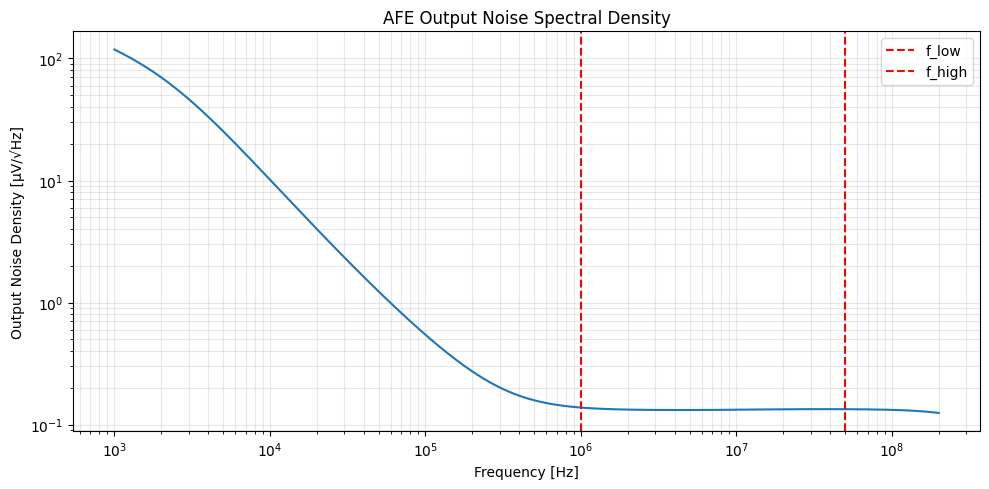

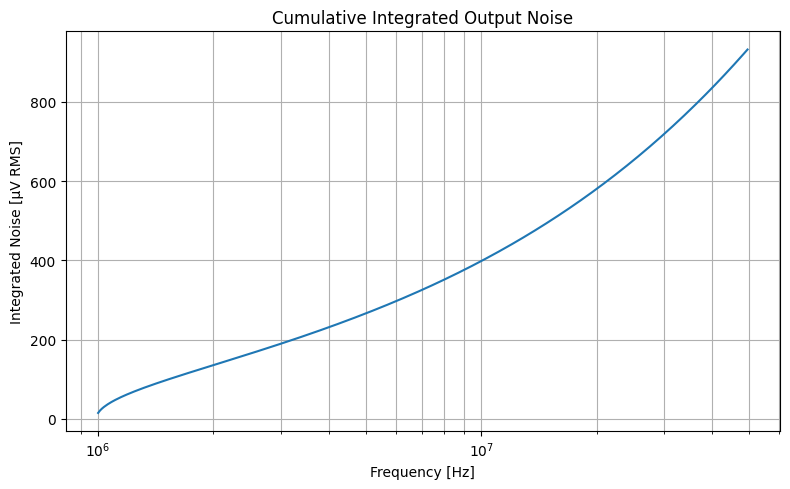

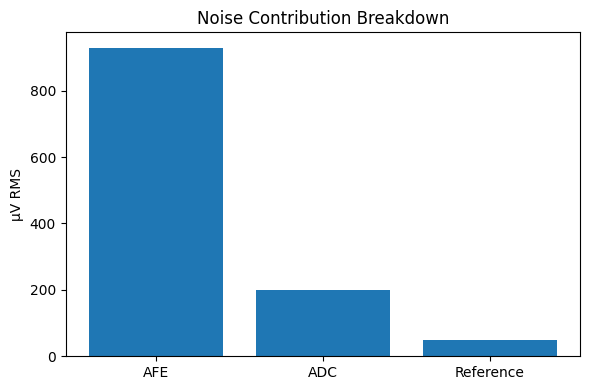


========== NOISE BUDGET ==========
Bandwidth:           1 – 50 MHz
AFE output noise:    929.27 µV rms
ADC noise:           200.00 µV rms
Reference noise:     50.00 µV rms
Total system noise:  951.86 µV rms
Input-referred:      929.27 nA rms


In [7]:
# ============================================
# STEP 4 — Load Simulation Data
# ============================================
from PyLTSpice import RawRead
import matplotlib.pyplot as plt
import numpy as np
import os

raw_path = '/workspace/Analysis/CircuitModels/AFE/TestBenchNoise.raw'
raw = RawRead(raw_path)

#raw = ltspice.Ltspice('/workspace/Analysis/CircuitModels/AFE/TestBenchNoise.raw')
#raw.parse()

freq = raw.get_trace('frequency').get_wave(0)
onoise = np.abs(raw.get_trace('V(onoise)').get_wave(0))

# ============================================
# STEP 5 — Define System Bandwidth
# ============================================
f_low = 1e6    # 1 MHz
f_high = 50e6  # 50 MHz

mask = (freq >= f_low) & (freq <= f_high)
freq_band = freq[mask]
onoise_band = onoise[mask]

# ============================================
# STEP 6 — Integrate Noise Numerically
# ============================================
output_noise_rms = np.sqrt(np.trapezoid(onoise_band**2, freq_band))
print(f"Output RMS noise (signal band): {output_noise_rms*1e6:.2f} µV")

# ============================================
# STEP 7 — Convert to Input-Referred Noise
# ============================================
Rf = 1e3  # TIA feedback resistor
input_noise_rms = output_noise_rms / Rf
print(f"Input-referred RMS noise: {input_noise_rms*1e9:.2f} nA")

# ============================================
# STEP 8 — Add Additional Noise Sources
# ============================================
# Datasheet values (example — replace with real numbers)
adc_noise_vrms = 200e-6      # ADC input noise
ref_noise_vrms = 50e-6       # Reference noise at output
sipm_shot_noise_vrms = 0     # Add if known

total_output_noise = np.sqrt(
    output_noise_rms**2 +
    adc_noise_vrms**2 +
    ref_noise_vrms**2 +
    sipm_shot_noise_vrms**2
)
print(f"Total system output noise: {total_output_noise*1e6:.2f} µV")

# ============================================
# PLOT — Noise Spectral Density
# ============================================
plt.figure(figsize=(10, 5))
plt.loglog(freq, onoise * 1e6)
plt.axvline(f_low, color='r', linestyle='--', label='f_low')
plt.axvline(f_high, color='r', linestyle='--', label='f_high')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Output Noise Density [µV/√Hz]')
plt.title('AFE Output Noise Spectral Density')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('noise_spectrum.png', dpi=150)
plt.show()

cumulative = np.sqrt(np.cumsum(onoise_band**2 * np.gradient(freq_band)))

# ============================================
# PLOT — Cumulative Integrated Noise vs Frequency
# ============================================

plt.figure(figsize=(8,5))
plt.semilogx(freq_band, cumulative * 1e6)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Integrated Noise [µV RMS]")
plt.title("Cumulative Integrated Output Noise")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

# ============================================
# PLOT — Noise Budget Contribution Bar Chart
# ============================================
labels = ['AFE', 'ADC', 'Reference']
values = [output_noise_rms, adc_noise_vrms, ref_noise_vrms]

plt.figure(figsize=(6,4))
plt.bar(labels, np.array(values)*1e6)
plt.ylabel("µV RMS")
plt.title("Noise Contribution Breakdown")
plt.tight_layout()
plt.show()


# ============================================
# SUMMARY TABLE
# ============================================
print("\n========== NOISE BUDGET ==========")
print(f"Bandwidth:           {f_low/1e6:.0f} – {f_high/1e6:.0f} MHz")
print(f"AFE output noise:    {output_noise_rms*1e6:.2f} µV rms")
print(f"ADC noise:           {adc_noise_vrms*1e6:.2f} µV rms")
print(f"Reference noise:     {ref_noise_vrms*1e6:.2f} µV rms")
print(f"Total system noise:  {total_output_noise*1e6:.2f} µV rms")
print(f"Input-referred:      {input_noise_rms*1e9:.2f} nA rms")
print("==================================")